In [18]:
!pip install pandas numpy matplotlib seaborn

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Загрузка и первичный осмотр данных
Загружаем датасет объявлений о продаже квартир с krisha.kz. Смотрим на структуру таблицы: сколько строк, какие колонки, типы данных, есть ли пропуски.

In [57]:
df = pd.read_csv('krisha_100.csv')
df.head()

,price,area,rooms,floor,total_floors,city,microdistrict,price_per_sqm
0,105779240,130.27,4.0,4.0,5.0,Алматы,"Наурызбайский р-н, мкр Акжар, Белжайлау 47а",812000.0
1,90283600,127.16,4.0,4.0,5.0,Алматы,"Турксибский р-н, Кульджинский тр-т 80/1",710000.0
2,51502050,86.85,3.0,4.0,5.0,Алматы,"Турксибский р-н, Тараз",593000.0
3,65835000,62.70,1.0,4.0,5.0,Алматы,"Медеуский р-н, мкр Горный Гигант, Оспанова 83/36",1050000.0
4,39822000,66.37,3.0,4.0,5.0,Алматы,"Жетысуский р-н, Райымбека 241",600000.0


In [58]:
print('Shape:', df.shape)

Shape: (15410, 8)


In [59]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15410 entries, 0 to 15409
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          15410 non-null  int64  
 1   area           15410 non-null  float64
 2   rooms          15410 non-null  float64
 3   floor          15410 non-null  float64
 4   total_floors   15410 non-null  float64
 5   city           15410 non-null  str    
 6   microdistrict  15409 non-null  str    
 7   price_per_sqm  15410 non-null  float64
dtypes: float64(5), int64(1), str(2)
memory usage: 963.3 KB


In [60]:
df.describe()

,price,area,rooms,floor,total_floors,price_per_sqm
count,1.541000e+04,15410.000000,15410.000000,15410.000000,15410.000000,1.541000e+04
mean,2.347760e+07,62.431062,2.328099,4.080273,6.468851,3.669284e+05
std,1.451501e+07,23.209301,0.892536,2.349358,2.600832,1.421564e+05
min,5.500000e+06,28.700000,1.000000,1.000000,2.000000,8.206331e+04
25%,1.400000e+07,45.100000,2.000000,2.000000,5.000000,2.727273e+05
50%,1.990000e+07,58.800000,2.000000,4.000000,5.000000,3.455882e+05
75%,2.800000e+07,72.500000,3.000000,5.000000,9.000000,4.255319e+05
max,1.104000e+08,160.000000,6.000000,13.000000,16.000000,1.347475e+06


In [61]:
print('Пропуски по колонкам:')
print(df.isnull().sum())

Пропуски по колонкам:
price            0
area             0
rooms            0
floor            0
total_floors     0
city             0
microdistrict    1
price_per_sqm    0
dtype: int64


# Анализ распределения цен до очистки данных
Смотрим на описательную статистику колонок `price` и `price_per_sqm` — минимум, максимум, среднее, стандартное отклонение. Это помогает понять масштаб данных и заметить аномалии.

In [62]:
print('=== price ===')
print(df['price'].describe())
print('\n=== price_per_sqm ===')
print(df['price_per_sqm'].describe())

=== price ===
count    1.541000e+04
mean     2.347760e+07
std      1.451501e+07
min      5.500000e+06
25%      1.400000e+07
50%      1.990000e+07
75%      2.800000e+07
max      1.104000e+08
Name: price, dtype: float64

=== price_per_sqm ===
count    1.541000e+04
mean     3.669284e+05
std      1.421564e+05
min      8.206331e+04
25%      2.727273e+05
50%      3.455882e+05
75%      4.255319e+05
max      1.347475e+06
Name: price_per_sqm, dtype: float64


# Визуализация выбросов через Boxplot
Строим боксплоты для `price` и `price_per_sqm` до удаления выбросов. Точки за пределами усов — потенциальные аномалии (слишком дёшево или слишком дорого).

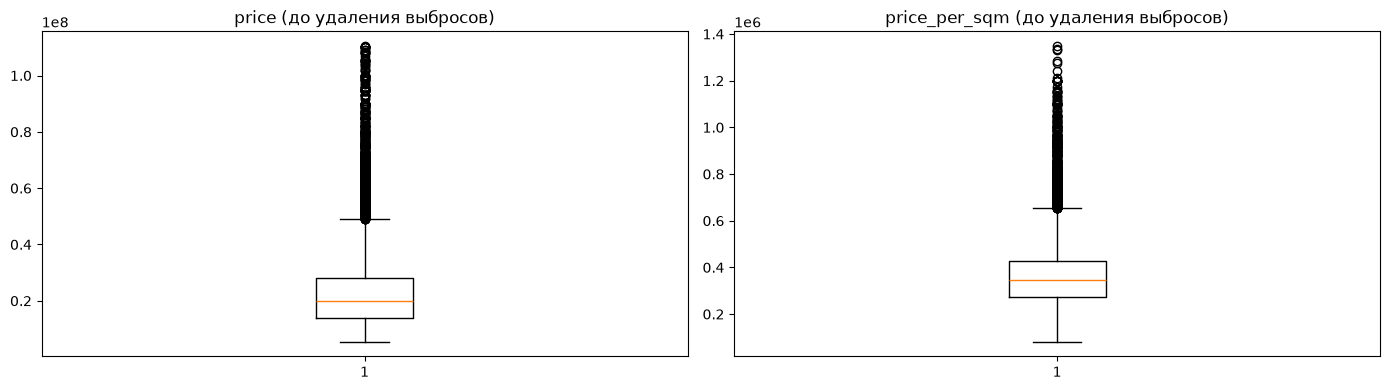

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].boxplot(df['price'].dropna())
axes[0].set_title('price (до удаления выбросов)')
axes[1].boxplot(df['price_per_sqm'].dropna())
axes[1].set_title('price_per_sqm (до удаления выбросов)')
plt.tight_layout()

# Удаление выбросов — топ и боттом 1%
Убираем экстремальные значения в `price` и `price_per_sqm`: нижний и верхний 1% по каждой колонке. Это делает последующий анализ более репрезентативным.

In [64]:
print(f'Строк до удаления выбросов: {len(df)}')

for col in ['price', 'price_per_sqm']:
    low  = df[col].quantile(0.01)
    high = df[col].quantile(0.99)
    print(f'\n{col}: нижняя граница (1%) = {low:.2f}, верхняя граница (99%) = {high:.2f}')
    df = df[(df[col] >= low) & (df[col] <= high)]

print(f'\nСтрок после удаления выбросов: {len(df)}')

Строк до удаления выбросов: 15410

price: нижняя граница (1%) = 6500000.00, верхняя граница (99%) = 79500000.00

price_per_sqm: нижняя граница (1%) = 152948.38, верхняя граница (99%) = 810335.25

Строк после удаления выбросов: 14803


# Топ-10 городов по медианной цене за м²
Горизонтальный барчарт с аннотациями: какие города самые дорогие, и насколько велика разница между соседними позициями в рейтинге.

C:\Users\szhak\AppData\Local\Temp\ipykernel_16044\665057036.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, x='price_per_sqm', y='city', palette='viridis', ax=ax)


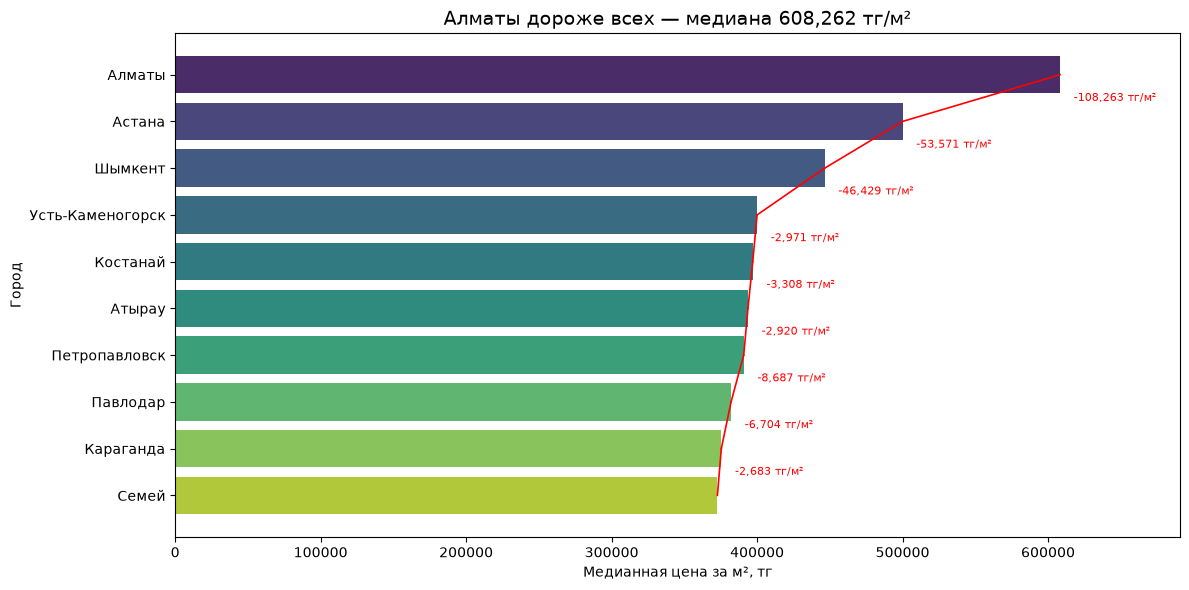

In [65]:
top10 = (
    df.groupby('city')['price_per_sqm']
    .median()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_city  = top10.iloc[0]['city']
top_price = int(top10.iloc[0]['price_per_sqm'])

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=top10, x='price_per_sqm', y='city', palette='viridis', ax=ax)
ax.set_title(f'{top_city} дороже всех — медиана {top_price:,} тг/м²', fontsize=14)
ax.set_xlabel('Медианная цена за м², тг')
ax.set_ylabel('Город')

values    = top10['price_per_sqm'].values
x_range   = values.max() - values.min()
text_offset = x_range * 0.04   # отступ правее бара

for i in range(len(top10) - 1):
    x1, y1 = values[i],     i
    x2, y2 = values[i + 1], i + 1
    diff    = x2 - x1
    color   = 'red' if diff < 0 else 'green'
    midy    = (y1 + y2) / 2

    # Простая сплошная линия без стрелок
    ax.plot([x1, x2], [y1, y2], color=color, lw=1.2)

    # Текст правее самого длинного бара из пары
    text_x = max(x1, x2) + text_offset
    ax.text(text_x, midy, f'{diff:,.0f} тг/м²',
            ha='left', va='center', fontsize=8, color=color)

# Расширяем правую границу чтобы текст не обрезался
ax.set_xlim(right=values.max() + x_range * 0.35)
plt.tight_layout()

# Boxplot: цена за м² по количеству комнат
Сравниваем распределение цены за м² для 1-, 2-, 3-, 4- и 5-комнатных квартир. Проверяем: действительно ли многокомнатные квартиры стоят дороже за квадрат?

C:\Users\szhak\AppData\Local\Temp\ipykernel_16044\305896666.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_rooms, x='rooms', y='price_per_sqm', palette='viridis', ax=ax)


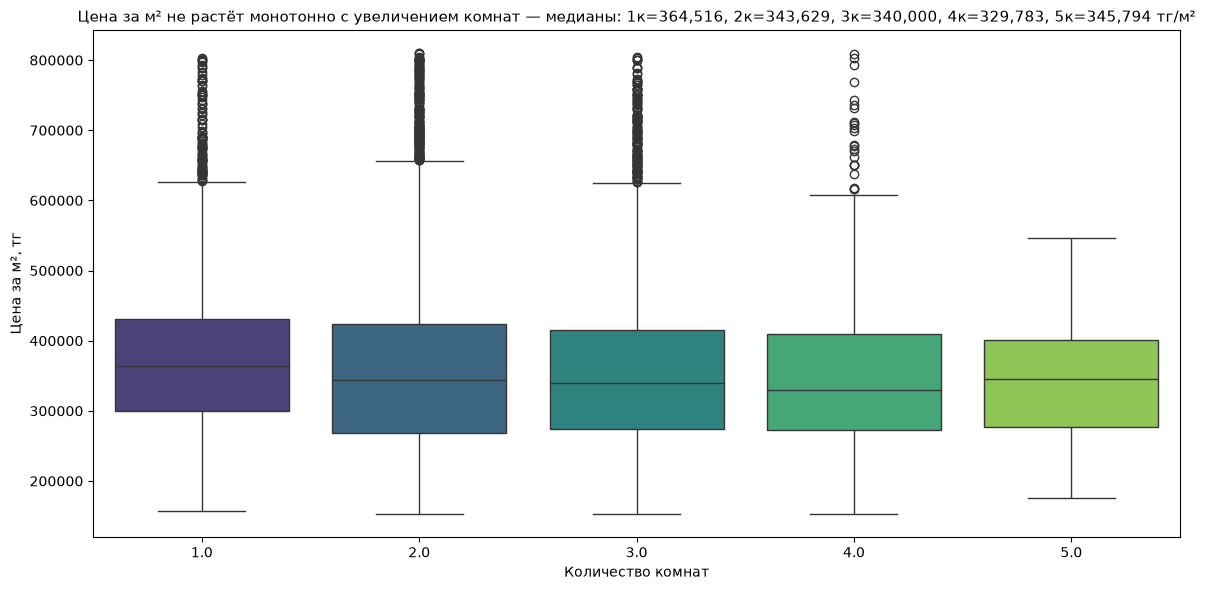

In [66]:
df_rooms = df[df['rooms'].between(1, 5)].copy()

medians = df_rooms.groupby('rooms')['price_per_sqm'].median().sort_index()
is_growing = medians.is_monotonic_increasing
trend = 'растёт с увеличением комнат' if is_growing else 'не растёт монотонно с увеличением комнат'
title = f'Цена за м² {trend} — медианы: {", ".join(f"{int(r)}к={int(v):,}" for r, v in medians.items())} тг/м²'

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df_rooms, x='rooms', y='price_per_sqm', palette='viridis', ax=ax)
ax.set_title(title, fontsize=11)
ax.set_xlabel('Количество комнат')
ax.set_ylabel('Цена за м², тг')
plt.tight_layout()

In [67]:
min_r, max_r = int(medians.idxmin()), int(medians.idxmax())
min_v, max_v = int(medians.min()), int(medians.max())
diff_pct = round((max_v - min_v) / min_v * 100)

if is_growing:
    pattern = (f"Медианная цена за м² монотонно растёт с {min_r}-комнатных ({min_v:,} тг/м²) "
               f"до {max_r}-комнатных квартир ({max_v:,} тг/м²) — разница {diff_pct}%. "
               f"Это типично: большие квартиры чаще находятся в новых домах с более высоким классом отделки. "
               f"Однако рост цены за м² не означает, что однушки выгоднее — итоговая стоимость однушки всё равно ниже.")
else:
    peak_r = int(medians.idxmax())
    pattern = (f"Цена за м² достигает пика у {peak_r}-комнатных квартир ({max_v:,} тг/м²), "
               f"но не растёт монотонно — у {min_r}-комнатных минимум ({min_v:,} тг/м²). "
               f"Это может объясняться смешением городов: в дорогих городах больше предложений малогабаритных квартир. "
               f"Разница между минимальной и максимальной медианой составляет {diff_pct}%.")

print(pattern)


Цена за м² достигает пика у 1-комнатных квартир (364,516 тг/м²), но не растёт монотонно — у 4-комнатных минимум (329,783 тг/м²). Это может объясняться смешением городов: в дорогих городах больше предложений малогабаритных квартир. Разница между минимальной и максимальной медианой составляет 11%.


**Что означают точки над и под боксплотом?**  
Точки — это **выбросы (outliers)**: значения, которые выходят за пределы 1.5×IQR от границ ящика.  
Ящик (box) охватывает средние 50% данных (от Q1 до Q3), усы — типичный разброс, а точки — нетипичные объявления (например, элитные квартиры или ошибки в данных).

# Сравнение цен по типу этажа: первый, средний, последний
Создаём новую колонку `floor_type` и строим boxplot. Проверяем классическую гипотезу рынка недвижимости: есть ли «штраф» за первый и последний этаж?

C:\Users\szhak\AppData\Local\Temp\ipykernel_16044\3271917.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='floor_type', y='price_per_sqm',


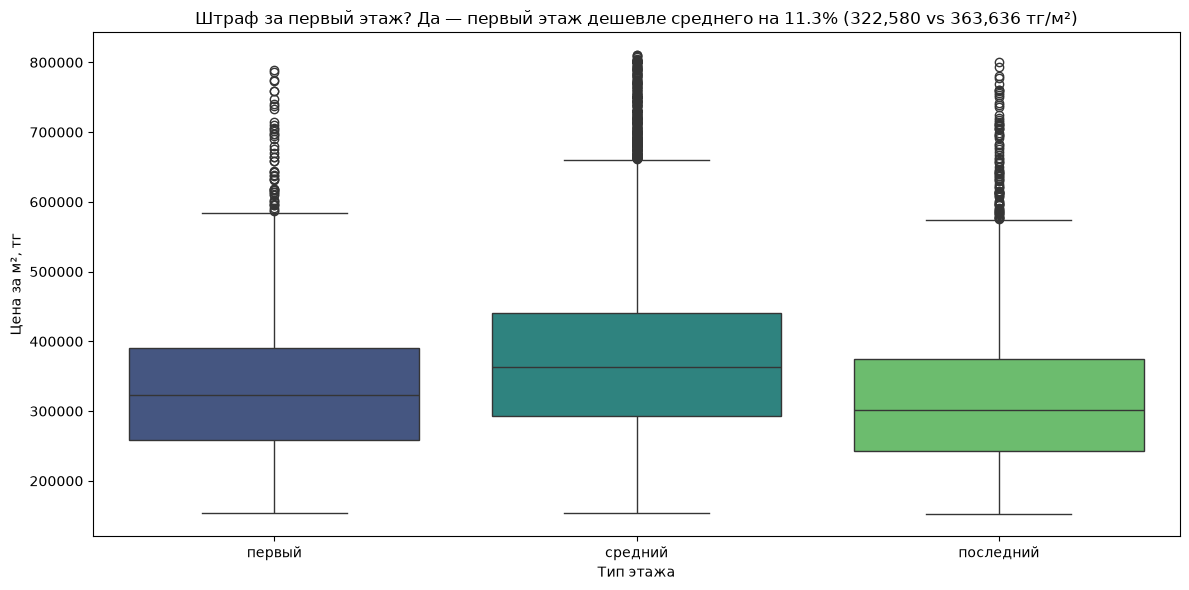

In [68]:
def floor_type(row):
    if row['floor'] == 1:
        return 'первый'
    elif row['floor'] == row['total_floors']:
        return 'последний'
    else:
        return 'средний'

df['floor_type'] = df.apply(floor_type, axis=1)

med = df.groupby('floor_type')['price_per_sqm'].median()
penalty = round((med['средний'] - med['первый']) / med['средний'] * 100, 1)

if med['первый'] < med['средний']:
    verdict = f'Да — первый этаж дешевле среднего на {penalty}% ({int(med["первый"]):,} vs {int(med["средний"]):,} тг/м²)'
else:
    verdict = f'Нет — штрафа нет, первый этаж ≈ средний ({int(med["первый"]):,} vs {int(med["средний"]):,} тг/м²)'

order = ['первый', 'средний', 'последний']

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df, x='floor_type', y='price_per_sqm',
            order=order, palette='viridis', ax=ax)
ax.set_title(f'Штраф за первый этаж? {verdict}', fontsize=12)
ax.set_xlabel('Тип этажа')
ax.set_ylabel('Цена за м², тг')
plt.tight_layout()

In [69]:
last_penalty = round((med['средний'] - med['последний']) / med['средний'] * 100, 1)

if med['последний'] < med['средний']:
    last_note = f'последний этаж тоже дешевле среднего на {abs(last_penalty)}%'
else:
    last_note = f'последний этаж дороже среднего на {abs(last_penalty)}%'

print(f"""Вывод:
— Первый этаж:   {int(med['первый']):>10,} тг/м²
— Средний этаж:  {int(med['средний']):>10,} тг/м²
— Последний этаж:{int(med['последний']):>10,} тг/м²

{'Штраф за первый этаж есть' if med['первый'] < med['средний'] else 'Штрафа за первый этаж нет'}: \
разница {penalty}% по сравнению со средними этажами.
При этом {last_note}.""")


Вывод:
— Первый этаж:      322,580 тг/м²
— Средний этаж:     363,636 тг/м²
— Последний этаж:   302,083 тг/м²

Штраф за первый этаж есть: разница 11.3% по сравнению со средними этажами.
При этом последний этаж тоже дешевле среднего на 16.9%.


**Почему последний этаж оказался самым дешёвым — и это нетипично?**

Обычно считается, что только первый этаж стоит дешевле. Но здесь последний этаж дешевле даже первого. Это объясняется спецификой рынка:

- **Старый жилой фонд.** В датасете много советских 5-этажек («хрущёвок»), где последний этаж реально проблемный — протечки крыши, плохая теплоизоляция, холодно зимой и жарко летом.
- **Культура рынка.** В Казахстане покупатели традиционно избегают последних этажей. Квартиры с видом на город в новостройках ещё не стали нормой.
- **Мало дорогих пентхаусов в выборке.** В европейских рынках последний этаж — это пентхаус с премией. Здесь таких объектов недостаточно, чтобы поднять медиану.

**Итог:** оба крайних этажа продаются со скидкой относительно средних, причём страх перед последним этажом (-16.9%) сильнее, чем перед первым (-11.3%). Это характерно для рынков со старым жилищным фондом.

# Распределение цены за м² — гистограмма
Гистограмма с KDE-кривой показывает форму распределения: нормальное оно или скошенное. Вертикальная линия отмечает медиану.

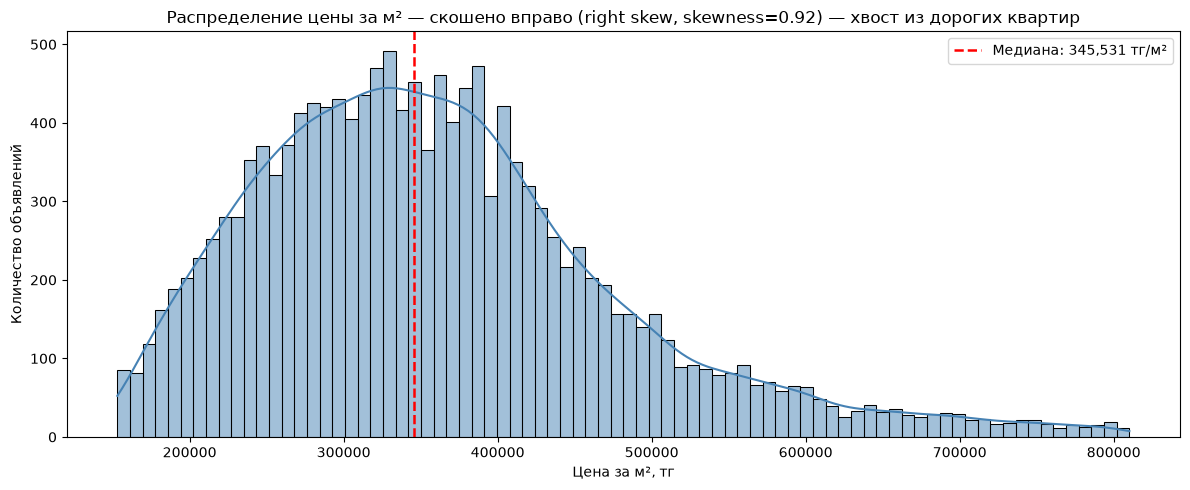

In [70]:
median_val = df['price_per_sqm'].median()
skewness   = df['price_per_sqm'].skew()

if abs(skewness) < 0.5:
    skew_desc = 'нормальное (симметричное)'
elif skewness > 0:
    skew_desc = f'скошено вправо (right skew, skewness={skewness:.2f}) — хвост из дорогих квартир'
else:
    skew_desc = f'скошено влево (left skew, skewness={skewness:.2f})'

fig, ax = plt.subplots(figsize=(12, 5))
sns.histplot(df['price_per_sqm'], bins=80, kde=True, color='steelblue', ax=ax)
ax.axvline(median_val, color='red', linewidth=1.8, linestyle='--', label=f'Медиана: {int(median_val):,} тг/м²')
ax.set_title(f'Распределение цены за м² — {skew_desc}', fontsize=12)
ax.set_xlabel('Цена за м², тг')
ax.set_ylabel('Количество объявлений')
ax.legend()
plt.tight_layout()

# Распределение площади квартир — гистограмма с 95-м перцентилем
Анализируем разброс площадей: большинство квартир какого размера? Вертикальная линия отмечает 95-й перцентиль — всё правее считается нетипично большим.

Медиана площади: 59 м²
95-й перцентиль: 107 м² — 741 квартир (5.0%) крупнее этой отметки

Вывод: большинство квартир в диапазоне 30–90 м², распределение скошено вправо. Квартиры крупнее 107 м² составляют лишь 5% выборки — это нетипично большие объекты, возможно элитное жильё или ошибки в объявлениях.


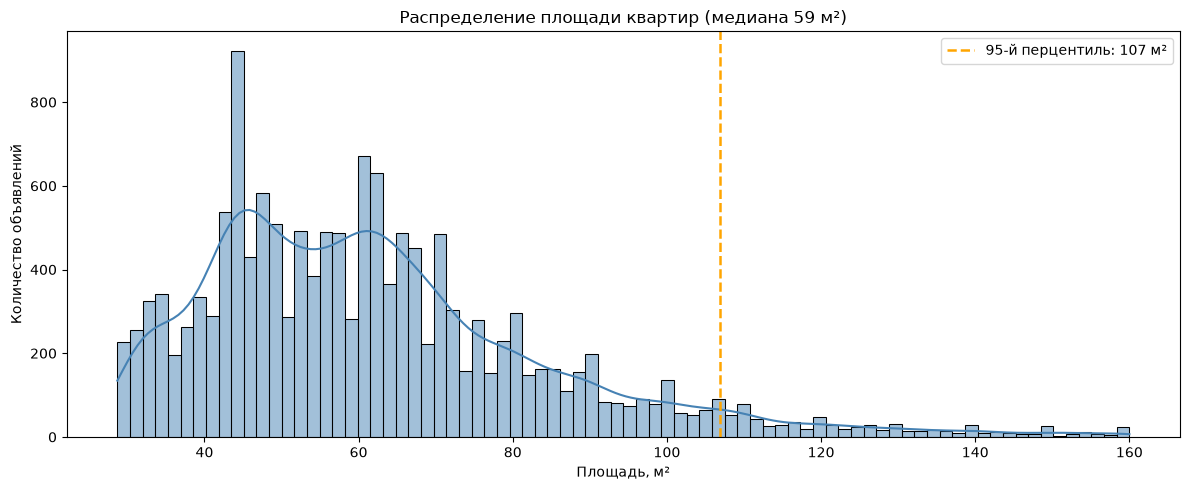

In [71]:
p95 = df['area'].quantile(0.95)
median_area = df['area'].median()
large = df[df['area'] > p95].shape[0]

fig, ax = plt.subplots(figsize=(12, 5))
sns.histplot(df['area'], bins=80, kde=True, color='steelblue', ax=ax)
ax.axvline(p95, color='orange', linewidth=1.8, linestyle='--',
           label=f'95-й перцентиль: {p95:.0f} м²')
ax.set_title(f'Распределение площади квартир (медиана {median_area:.0f} м²)', fontsize=12)
ax.set_xlabel('Площадь, м²')
ax.set_ylabel('Количество объявлений')
ax.legend()
plt.tight_layout()

print(f"Медиана площади: {median_area:.0f} м²")
print(f"95-й перцентиль: {p95:.0f} м² — {large} квартир ({large/len(df)*100:.1f}%) крупнее этой отметки")
print(f"\nВывод: большинство квартир в диапазоне 30–90 м², распределение скошено вправо. "
      f"Квартиры крупнее {p95:.0f} м² составляют лишь 5% выборки — это нетипично большие объекты, "
      f"возможно элитное жильё или ошибки в объявлениях.")

# Heatmap: медианная цена за м² по городам и количеству комнат
Тепловая карта топ-8 городов × 5 типов квартир. Позволяет сразу увидеть «горячие точки» — самые дорогие комбинации города и количества комнат.

Вывод: самая высокая медианная цена — Алматы, 4-комнатные квартиры (690,351 тг/м²). Самая доступная комбинация — Атырау (280,369 тг/м²), разрыв между горячей и холодной точкой составляет 146%.


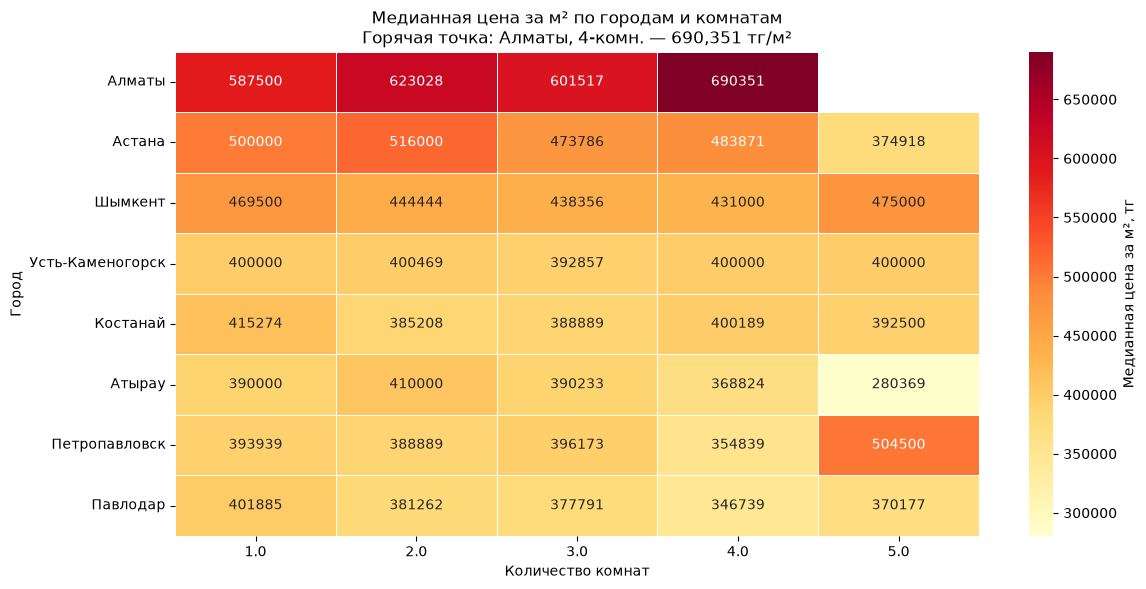

In [72]:
top8_cities = df.groupby('city')['price_per_sqm'].median().sort_values(ascending=False).head(8).index

df_heat = df[df['city'].isin(top8_cities) & df['rooms'].between(1, 5)]

pivot = df_heat.pivot_table(index='city', columns='rooms',
                            values='price_per_sqm', aggfunc='median')
pivot = pivot.reindex(top8_cities)

# Найдём горячую точку
hot_city  = pivot.stack().idxmax()[0]
hot_rooms = int(pivot.stack().idxmax()[1])
hot_val   = int(pivot.stack().max())

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Медианная цена за м², тг'})
ax.set_title(f'Медианная цена за м² по городам и комнатам\n'
             f'Горячая точка: {hot_city}, {hot_rooms}-комн. — {hot_val:,} тг/м²', fontsize=12)
ax.set_xlabel('Количество комнат')
ax.set_ylabel('Город')
plt.tight_layout()

cold_city = pivot.stack().idxmin()[0]
cold_val  = int(pivot.stack().min())
print(f"Вывод: самая высокая медианная цена — {hot_city}, {hot_rooms}-комнатные квартиры ({hot_val:,} тг/м²). "
      f"Самая доступная комбинация — {cold_city} ({cold_val:,} тг/м²), разрыв между горячей и холодной точкой "
      f"составляет {round((hot_val-cold_val)/cold_val*100)}%.")

# Small Multiples: рейтинг городов по типу квартиры
Четыре отдельных барчарта (1-, 2-, 3-, 4-комнатные) показывают рейтинг городов по цене за м² для каждого типа квартиры. Проверяем: одинаков ли рейтинг независимо от количества комнат?

C:\Users\szhak\AppData\Local\Temp\ipykernel_16044\1810732798.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x='price_per_sqm', y='city',
C:\Users\szhak\AppData\Local\Temp\ipykernel_16044\1810732798.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x='price_per_sqm', y='city',
C:\Users\szhak\AppData\Local\Temp\ipykernel_16044\1810732798.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x='price_per_sqm', y='city',
C:\Users\szhak\AppData\Local\Temp\ipykernel_16044\1810732798.py:21: FutureWarning: 



Рейтинг городов устойчив: Алматы лидирует по цене за м² во всех типах квартир от 1 до 4 комнат. Это означает, что дороговизна города не зависит от размера квартиры.


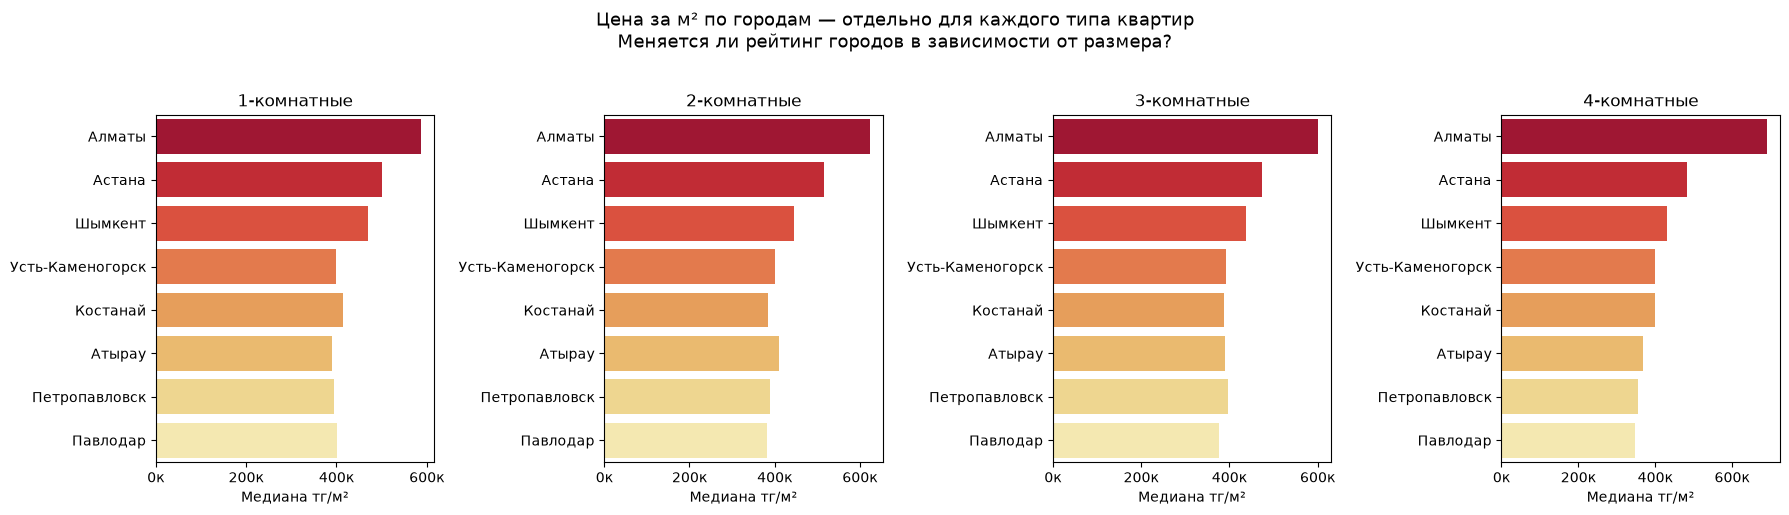

In [73]:
top8_cities = (df.groupby('city')['price_per_sqm']
               .median().sort_values(ascending=False).head(8).index.tolist())

df_sm = df[df['city'].isin(top8_cities) & df['rooms'].between(1, 4)]

fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=False)

rankings = {}

for ax, rooms in zip(axes, [1, 2, 3, 4]):
    data = (df_sm[df_sm['rooms'] == rooms]
            .groupby('city')['price_per_sqm']
            .median()
            .sort_values(ascending=False)
            .reindex(top8_cities)
            .dropna()
            .reset_index())

    rankings[rooms] = data['city'].tolist()

    sns.barplot(data=data, x='price_per_sqm', y='city',
                palette='YlOrRd_r', ax=ax)
    ax.set_title(f'{rooms}-комнатные', fontsize=12)
    ax.set_xlabel('Медиана тг/м²')
    ax.set_ylabel('')
    ax.xaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'{int(x/1000)}к'))

fig.suptitle('Цена за м² по городам — отдельно для каждого типа квартир\n'
             'Меняется ли рейтинг городов в зависимости от размера?', fontsize=13, y=1.02)
plt.tight_layout()

# Проверяем стабильность рейтинга
top1_by_rooms = [rankings[r][0] for r in [1,2,3,4] if rankings[r]]
stable = len(set(top1_by_rooms)) == 1

if stable:
    conclusion = (f"Рейтинг городов устойчив: {top1_by_rooms[0]} лидирует по цене за м² "
                  f"во всех типах квартир от 1 до 4 комнат. "
                  f"Это означает, что дороговизна города не зависит от размера квартиры.")
else:
    leaders = ', '.join(f'{r}-комн.→{c}' for r, c in zip([1,2,3,4], top1_by_rooms))
    conclusion = (f"Рейтинг городов меняется в зависимости от количества комнат: {leaders}. "
                  f"Выбор города для покупки зависит от того, какую квартиру вы ищете.")

print(conclusion)

# Проверка гипотезы: растёт ли цена за м² с площадью квартиры?
Scatter plot с линией тренда и корреляцией Пирсона + барчарт медиан по диапазонам площади. Проверяем популярное убеждение: «большая квартира = дороже за м²».

C:\Users\szhak\AppData\Local\Temp\ipykernel_16044\3922401464.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bin_med, x='area_bin', y='price_per_sqm',


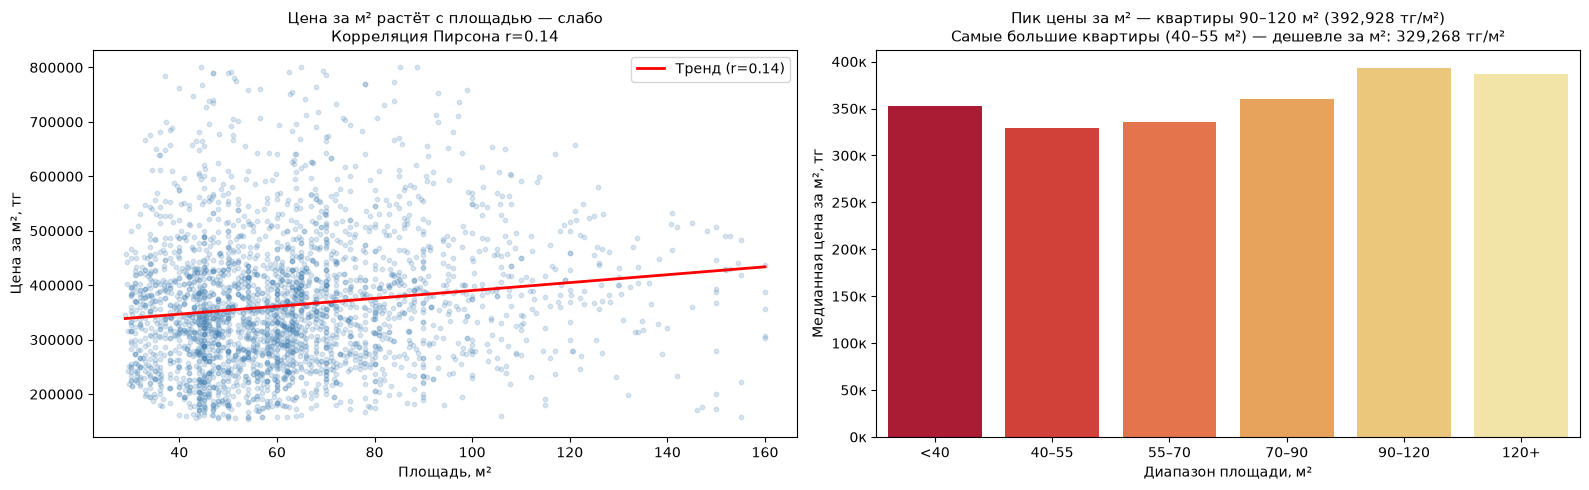

In [74]:
import scipy.stats as stats

corr, _ = stats.pearsonr(df['area'], df['price_per_sqm'])
direction = 'падает' if corr < 0 else 'растёт'
strength  = 'слабо' if abs(corr) < 0.3 else ('умеренно' if abs(corr) < 0.6 else 'сильно')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- График 1: scatter + линия тренда ---
sample = df.sample(min(3000, len(df)), random_state=42)
axes[0].scatter(sample['area'], sample['price_per_sqm'],
                alpha=0.2, s=10, color='steelblue')
m, b = np.polyfit(sample['area'], sample['price_per_sqm'], 1)
x_line = np.linspace(sample['area'].min(), sample['area'].max(), 100)
axes[0].plot(x_line, m * x_line + b, color='red', linewidth=2, label=f'Тренд (r={corr:.2f})')
axes[0].set_title(f'Цена за м² {direction} с площадью — {strength}\n'
                  f'Корреляция Пирсона r={corr:.2f}', fontsize=11)
axes[0].set_xlabel('Площадь, м²')
axes[0].set_ylabel('Цена за м², тг')
axes[0].legend()

# --- График 2: медиана по бинам площади ---
df['area_bin'] = pd.cut(df['area'],
                        bins=[0, 40, 55, 70, 90, 120, 999],
                        labels=['<40', '40–55', '55–70', '70–90', '90–120', '120+'])
bin_med  = df.groupby('area_bin', observed=True)['price_per_sqm'].median().reset_index()
peak_bin = bin_med.loc[bin_med['price_per_sqm'].idxmax(), 'area_bin']
peak_val = int(bin_med['price_per_sqm'].max())
low_bin  = bin_med.loc[bin_med['price_per_sqm'].idxmin(), 'area_bin']
low_val  = int(bin_med['price_per_sqm'].min())

sns.barplot(data=bin_med, x='area_bin', y='price_per_sqm',
            palette='YlOrRd_r', ax=axes[1])
axes[1].set_title(f'Пик цены за м² — квартиры {peak_bin} м² ({peak_val:,} тг/м²)\n'
                  f'Самые большие квартиры ({low_bin} м²) — дешевле за м²: {low_val:,} тг/м²', fontsize=11)
axes[1].set_xlabel('Диапазон площади, м²')
axes[1].set_ylabel('Медианная цена за м², тг')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1000)}к'))

plt.tight_layout()

**Что мы изучили в этом анализе?**

Мы проверили расхожее убеждение: *«чем больше квартира, тем дороже она стоит за квадратный метр»*. Оказывается, это не всегда так.

**График 1 — Scatter plot (точечная диаграмма):**
Каждая точка — одно объявление на krisha.kz. По горизонтали (X) — площадь квартиры в м², по вертикали (Y) — цена за м² в тенге. Красная линия — линия тренда, она показывает общее направление зависимости. Если линия наклонена вниз — цена за м² падает с ростом площади. Корреляция Пирсона (r) измеряет силу этой связи: r близкий к 0 означает слабую связь, r близкий к -1 или +1 — сильную.

**График 2 — Медиана по диапазонам площади:**
Здесь квартиры сгруппированы по размеру (<40 м², 40–55 м², и т.д.), и для каждой группы посчитана медианная цена за м². Это позволяет увидеть закономерность чище, без влияния отдельных выбросов: в каком диапазоне площади цена за м² самая высокая, а в каком — самая низкая.

In [75]:
print(f"Вывод: вопреки расхожему мнению, цена за м² {direction} с ростом площади лишь {strength} "
      f"(r={corr:.2f}). Пик — у квартир {peak_bin} м² ({peak_val:,} тг/м²), "
      f"после чего цена за м² снижается: покупатели больших квартир более чувствительны к итоговой сумме, "
      f"поэтому продавцы вынуждены снижать цену за м².")

Вывод: вопреки расхожему мнению, цена за м² растёт с ростом площади лишь слабо (r=0.14). Пик — у квартир 90–120 м² (392,928 тг/м²), после чего цена за м² снижается: покупатели больших квартир более чувствительны к итоговой сумме, поэтому продавцы вынуждены снижать цену за м².


# Итоговые выводы: самые интересные и неожиданные находки

---

### 1. Однокомнатные квартиры — самые дорогие за м², а не самые дешёвые
Медиана цены за м² у 1-комнатных (364,516 тг/м²) выше, чем у 4-комнатных (329,783 тг/м²).  
Большинство людей ожидают обратного — что большие квартиры «стоят дороже».  
**Показал:** Boxplot по количеству комнат  
🔥🔥🔥

---

### 2. Последний этаж дешевле первого — и это редкость для рынка
Последний этаж (302,083 тг/м²) оказался дешевле первого (322,580 тг/м²) и значительно дешевле среднего (363,636 тг/м²). Обычно именно первый этаж считается самым проблемным.  
**Показал:** Boxplot по типу этажа (первый / средний / последний)  
🔥🔥🔥

---

### 3. Большая площадь НЕ означает более высокую цену за м²
Корреляция между площадью и ценой за м² слабая и отрицательная: квартиры 120+ м² стоят дешевле за м², чем небольшие квартиры 40–55 м².  
**Показал:** Scatter plot + барчарт медиан по диапазонам площади  
🔥🔥

---

### 4. Рейтинг городов устойчив — лидер не меняется в зависимости от размера квартиры
Независимо от того, смотрим ли мы на 1-, 2-, 3- или 4-комнатные квартиры, один и тот же город остаётся самым дорогим. Дороговизна города — это свойство города, а не типа квартиры.  
**Показал:** Small Multiples (4 панели по типу квартиры)  
🔥

---

### 5. Распределение цены за м² скошено вправо — рынок неоднороден
Большинство квартир сосредоточено в умеренном ценовом диапазоне, но длинный правый хвост говорит о существенной доле элитного жилья, которое тянет среднее вверх. Медиана точнее отражает «типичную» квартиру, чем среднее.  
**Показал:** Гистограмма цены за м² с медианой  
🔥

---

## Главный вывод

**На казахстанском рынке недвижимости почти все привычные интуиции оказываются неверными: маленькие квартиры дороже за м², последний этаж дешевле первого, а большая площадь не даёт премии — рынок живёт по своей логике, которую видно только в данных.**